# Tutorial: Machine Learning with Text in scikit-learn

# Note from Donny

This combines: Kevin Markham's Text Learning Tutorial<br>
Some Information from Wikipedia<br>
And some stuff on TF-IDF

## Agenda

1. Model building in scikit-learn (refresher)
2. Representing text as numerical data
3. Reading a text-based dataset into pandas
4. Vectorizing our dataset
5. Building and evaluating a model
6. Comparing models
7. Performing Cross-Validation to select C
8. Tuning the vectorizer (discussion)
9. TF-IDF Vectorizer plus model

## Part 1: Model building in scikit-learn (refresher)

In [1]:
# load the iris dataset as an example
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
# store the feature matrix (X) and response vector (y)
X = iris.data
y = iris.target

**"Features"** are also known as predictors, inputs, or attributes. The **"response"** is also known as the target, label, or output.

In [3]:
# check the shapes of X and y
print(X.shape)
print(y.shape)

(150, 4)
(150,)


**"Observations"** are also known as samples, instances, or records.

In [4]:
# examine the first 5 rows of the feature matrix (including the feature names)
import pandas as pd
pd.DataFrame(X, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# examine the response vector
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In order to **build a model**, the features must be **numeric**, and every observation must have the **same features in the same order**.

In [6]:
# import the class
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model (with the default parameters)
knn = KNeighborsClassifier()

# fit the model with data (occurs in-place)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In order to **make a prediction**, the new observation must have the **same features as the training observations**, both in number and meaning.

In [7]:
# predict the response for a new observation
knn.predict([[3, 5, 4, 2]])

array([1])

## Part 2: Representing text as numerical data

In [8]:
# example text for model training (SMS messages)
simple_train = ['call you tonight', 'Call me a cab', 'please call me... PLEASE!']

From the [scikit-learn documentation](http://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction):

> Text Analysis is a major application field for machine learning algorithms. However the raw data, a sequence of symbols cannot be fed directly to the algorithms themselves as most of them expect **numerical feature vectors with a fixed size** rather than the **raw text documents with variable length**.

We will use [CountVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) to "convert text into a matrix of token counts":

In [9]:
# import and instantiate CountVectorizer (with the default parameters)
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()

In [10]:
# learn the 'vocabulary' of the training data (occurs in-place)
vect.fit(simple_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [11]:
simple_train

['call you tonight', 'Call me a cab', 'please call me... PLEASE!']

In [12]:
# examine the fitted vocabulary
vect.get_feature_names_out()

array(['cab', 'call', 'me', 'please', 'tonight', 'you'], dtype=object)

In [13]:
# transform training data into a 'document-term matrix'
simple_train_dtm = vect.transform(simple_train)
simple_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (3, 6)>

In [14]:
simple_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (3, 6)>

In [15]:
# convert sparse matrix to a dense matrix
simple_train_dtm.toarray()

array([[0, 1, 0, 0, 1, 1],
       [1, 1, 1, 0, 0, 0],
       [0, 1, 1, 2, 0, 0]])

In [16]:
# examine the vocabulary and document-term matrix together
pd.DataFrame(simple_train_dtm.toarray(), columns=vect.get_feature_names_out())

,cab,call,me,please,tonight,you
0,0,1,0,0,1,1
1,1,1,1,0,0,0
2,0,1,1,2,0,0


From the [scikit-learn documentation](http://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction):

> In this scheme, features and samples are defined as follows:

> - Each individual token occurrence frequency (normalized or not) is treated as a **feature**.
> - The vector of all the token frequencies for a given document is considered a multivariate **sample**.

> A **corpus of documents** can thus be represented by a matrix with **one row per document** and **one column per token** (e.g. word) occurring in the corpus.

> We call **vectorization** the general process of turning a collection of text documents into numerical feature vectors. This specific strategy (tokenization, counting and normalization) is called the **Bag of Words** or "Bag of n-grams" representation. Documents are described by word occurrences while completely ignoring the relative position information of the words in the document.

In [17]:
# check the type of the document-term matrix
type(simple_train_dtm)

scipy.sparse._csr.csr_matrix

In [18]:
# examine the sparse matrix contents
print(simple_train_dtm)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (3, 6)>
  Coords	Values
  (0, 1)	1
  (0, 4)	1
  (0, 5)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	2


From the [scikit-learn documentation](http://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction):

> As most documents will typically use a very small subset of the words used in the corpus, the resulting matrix will have **many feature values that are zeros** (typically more than 99% of them).

> For instance, a collection of 10,000 short text documents (such as emails) will use a vocabulary with a size in the order of 100,000 unique words in total while each document will use 100 to 1000 unique words individually.

> In order to be able to **store such a matrix in memory** but also to **speed up operations**, implementations will typically use a **sparse representation** such as the implementations available in the `scipy.sparse` package.

In [19]:
# example text for model testing
simple_test = ["please don't call me"]

In order to **make a prediction**, the new observation must have the **same features as the training observations**, both in number and meaning.

In [20]:
# transform testing data into a document-term matrix (using existing vocabulary)
simple_test_dtm = vect.transform(simple_test)
simple_test_dtm.toarray()

array([[0, 1, 1, 1, 0, 0]])

In [21]:
# examine the vocabulary and document-term matrix together
pd.DataFrame(simple_test_dtm.toarray(), columns=vect.get_feature_names_out())

,cab,call,me,please,tonight,you
0,0,1,1,1,0,0


**Summary:**

- `vect.fit(train)` **learns the vocabulary** of the training data
- `vect.transform(train)` uses the **fitted vocabulary** to build a document-term matrix from the training data
- `vect.transform(valid)` uses the **fitted vocabulary** to build a document-term matrix from the validation data (and **ignores tokens** it hasn't seen before)

## Part 3: Reading a text-based dataset into pandas

Now you are going to do some things.

In [22]:
# read file into pandas using a relative path sms.tsv
path = 'sms.tsv'
sms = pd.read_table(path, header=None, names=['label', 'message'])

Check the .head() as usual, did read_table work correctly? Do you need to set any parameters such as header or names?

We want the columns to have names <i>label</i> and <i>message</i>

In [23]:
# Verify the read worked correctly
sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
# examine the shape
sms.shape

(5572, 2)

Examine the first 10 rows

In [25]:
# examine the first 10 rows
sms.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [26]:
# examine the class distribution
sms.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [27]:
# convert label to a numerical variable
sms['label_num'] = sms.label.map({'ham':0, 'spam':1})

In [28]:
# check that the conversion worked
sms.head(10)

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


In [29]:
# Identify what will be the response variable and what will be the set of features, the X and y
X = sms.message
y = sms.label_num
print(X.shape)
print(y.shape)

(5572,)
(5572,)


In [30]:
# split X and y into training and validation sets - train_test_split with random_state=1138 so we all get the same
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=1138, test_size=0.3)
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(3900,)
(1672,)
(3900,)
(1672,)


## Part 4: Vectorizing our dataset

In [31]:
# instantiate the vectorizer
vect = CountVectorizer()

### Notice

The Vectorizer (the vocabulary) is only built on the Training Set of Data. Can anyone tell me why?

The Vectorizer needs to be "fit" like a ML algorithm. Fit the <i>vect</i> with X_train

In [32]:
# Fit the vectorizer with X_train
vect.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


You now need to create a dtm (document term matrix) like above by transforming the text into a matrix

In [33]:
# Transform X_train into document-term matrix
X_train_dtm = vect.transform(X_train)

In [34]:
# examine the document-term matrix
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 52250 stored elements and shape (3900, 7269)>

In [35]:
import numpy as np

In [36]:
for row in X_train_dtm.toarray():
     print(row)

[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 1 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ...

In [37]:
X_train_dtm.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

The test data is transformed to the already fitted vocabulary. Words that were not in the original training set are ignored (our model would not know what to do with them). 

We could, of course, built this all as a pipeline using make_pipeline

In [38]:
# transform testing data (using fitted vocabulary) into a document-term matrix
X_valid_dtm = vect.transform(X_valid)

## Part 5: Building and evaluating a model

We will use LogisticRegression to start with the default settings:

In [39]:
# import and instantiate a LogisticRegression model
from sklearn.linear_model import LogisticRegression
nb = LogisticRegression(max_iter=1000)

Note: X_train_dtm is a sparse matrix, LogisticRegression understands sparse matrices, some models may have to do conversions.

In [40]:
# train the model using X_train_dtm (timing it with an IPython "magic command")
%time nb.fit(X_train_dtm, y_train)

CPU times: user 65.1 ms, sys: 72.3 ms, total: 137 ms
Wall time: 21.7 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
# make class predictions for X_valid_dtm
y_pred_class = nb.predict(X_valid_dtm)

In [42]:
# calculate accuracy of class predictions
from sklearn import metrics
metrics.accuracy_score(y_valid, y_pred_class)

0.9832535885167464

In [43]:
nb.score(X_valid_dtm, y_valid)

0.9832535885167464

In [44]:
# print the confusion matrix
metrics.confusion_matrix(y_valid, y_pred_class)

array([[1443,    5],
       [  23,  201]])

In [45]:
# print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_valid, y_pred_class))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.98      0.90      0.93       224

    accuracy                           0.98      1672
   macro avg       0.98      0.95      0.96      1672
weighted avg       0.98      0.98      0.98      1672



In [46]:
# print out all the "wrong" ones
X_valid[y_pred_class != y_valid]

1777                    Call FREEPHONE 0800 542 0578 now!
2965    Do you ever notice that when you're driving, a...
4144    In The Simpsons Movie released in July 2007 na...
4661    You call him and tell now infront of them. Cal...
19      England v Macedonia - dont miss the goals/team...
1893    CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...
305     SMS. ac Blind Date 4U!: Rodds1 is 21/m from Ab...
763     Urgent Ur £500 guaranteed award is still uncla...
1097    Dear Subscriber ur draw 4 £100 gift voucher wi...
2247    Hi ya babe x u 4goten bout me?' scammers getti...
2402    Babe: U want me dont u baby! Im nasty and have...
1449    As a registered optin subscriber ur draw 4 £10...
3460    Not heard from U4 a while. Call me now am here...
495                      Are you free now?can i call now?
2774    How come it takes so little time for a child w...
4729    I (Career Tel) have added u as a contact on IN...
1430    For sale - arsenal dartboard. Good condition b...
788     Ever t

In [47]:
# print message text for the false positives (ham incorrectly classified as spam)
X_valid[(y_pred_class==1) & (y_valid==0)] # or X_valid[y_pred_class > y_valid]

4661    You call him and tell now infront of them. Cal...
495                      Are you free now?can i call now?
4729    I (Career Tel) have added u as a contact on IN...
2521    Misplaced your number and was sending texts to...
1325    Can you call me plz. Your number shows out of ...
Name: message, dtype: object

In [48]:
# print message text for the false negatives (spam incorrectly classified as ham)
X_valid[(y_pred_class==0) & (y_valid==1)]

1777                    Call FREEPHONE 0800 542 0578 now!
2965    Do you ever notice that when you're driving, a...
4144    In The Simpsons Movie released in July 2007 na...
19      England v Macedonia - dont miss the goals/team...
1893    CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...
305     SMS. ac Blind Date 4U!: Rodds1 is 21/m from Ab...
763     Urgent Ur £500 guaranteed award is still uncla...
1097    Dear Subscriber ur draw 4 £100 gift voucher wi...
2247    Hi ya babe x u 4goten bout me?' scammers getti...
2402    Babe: U want me dont u baby! Im nasty and have...
1449    As a registered optin subscriber ur draw 4 £10...
3460    Not heard from U4 a while. Call me now am here...
2774    How come it takes so little time for a child w...
1430    For sale - arsenal dartboard. Good condition b...
788     Ever thought about living a good life with a p...
4394    RECPT 1/3. You have ordered a Ringtone. Your o...
761     Romantic Paris. 2 nights, 2 flights from £79 B...
4676    Hi bab

In [49]:
# example false negative
X_valid[(y_pred_class==0) & (y_valid==1)].head(1)

1777    Call FREEPHONE 0800 542 0578 now!
Name: message, dtype: object

In [50]:
# calculate predicted probabilities for X_valid_dtm (poorly calibrated probabilities)
y_pred_prob = nb.predict_proba(X_valid_dtm)[:, 1]
y_pred_prob

array([1.28397795e-03, 6.22873108e-03, 9.94267564e-01, ...,
       7.91330261e-04, 9.94910847e-01, 2.91492126e-02])

In [51]:
# calculate AUC - another metric for measure the performance of a classification system, it relies on probabilities. 
# I briefly mentioned it in lectures
metrics.roc_auc_score(y_valid, y_pred_prob)

0.9862926696921862

## Part 6: Comparing models

We will compare LogisticRegression with a linear Support Vector Classifier and Random Forests:

Probability=True makes it take a bit longer to train but it will allow us to calculate the roc_auc score

In [52]:
# import and instantiate a SVC model
from sklearn.svm import SVC
svcmodel = SVC(kernel='linear', probability=True)


In [53]:
# train the model using X_train_dtm
%time svcmodel.fit(X_train_dtm, y_train)

CPU times: user 1.09 s, sys: 61.3 ms, total: 1.15 s
Wall time: 1.08 s


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [54]:
# make class predictions for X_valid_dtm
y_pred_class = svcmodel.predict(X_valid_dtm)

In [55]:
# calculate predicted probabilities for X_valid_dtm (well calibrated)
y_pred_prob = svcmodel.predict_proba(X_valid_dtm)[:, 1]

In [56]:
# calculate accuracy
metrics.accuracy_score(y_valid, y_pred_class)

0.9892344497607656

In [57]:
# calculate AUC
metrics.roc_auc_score(y_valid, y_pred_prob)

0.987726297355959

Now do Random Forests

In [58]:
# import and instantiate a RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=1138)

In [59]:
# train the model
%time rf.fit(X_train_dtm, y_train)

CPU times: user 343 ms, sys: 4.58 ms, total: 347 ms
Wall time: 347 ms


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Part 7: Cross Validation

Now you want to do some form of cross-validation with SVC, find the best 'C', use GridSearchCV or whatever method was your favourite. Find the best cross-validation score. You can set probability=False this time around and just use the accuracy score to compare

Same with Random Forest

In [60]:
# Cross-validation with GridSearchCV for SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'C': [0.1, 1, 10, 100]}

# Create GridSearchCV object
grid_svc = GridSearchCV(SVC(kernel='linear', probability=True), 
                        param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
%time grid_svc.fit(X_train_dtm, y_train)

CPU times: user 1.12 s, sys: 91.7 ms, total: 1.21 s
Wall time: 5.41 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='l...bability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

In [61]:
# Show best parameters and score
print('Best parameters:', grid_svc.best_params_)
print('Best cross-validation score:', grid_svc.best_score_)

Best parameters: {'C': 1}
Best cross-validation score: 0.9815384615384616


In [62]:
# Evaluate on validation set
y_pred = grid_svc.predict(X_valid_dtm)
print('Validation accuracy:', metrics.accuracy_score(y_valid, y_pred))
print('Validation AUC:', metrics.roc_auc_score(y_valid, grid_svc.predict_proba(X_valid_dtm)[:, 1]))

Validation accuracy: 0.9892344497607656
Validation AUC: 0.987726297355959


Now find the best 'C' with LogisticRegression using cross-validation, again find the best cross-validation score.

In [63]:
# Cross-validation with GridSearchCV for LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Create GridSearchCV object
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), 
                       param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
%time grid_lr.fit(X_train_dtm, y_train)

CPU times: user 204 ms, sys: 10.6 ms, total: 214 ms
Wall time: 112 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [64]:
# Show best parameters and score
print('Best parameters:', grid_lr.best_params_)
print('Best cross-validation score:', grid_lr.best_score_)

Best parameters: {'C': 100}
Best cross-validation score: 0.9823076923076922


In [65]:
# Evaluate on validation set
y_pred = grid_lr.predict(X_valid_dtm)
print('Validation accuracy:', metrics.accuracy_score(y_valid, y_pred))
print('Validation AUC:', metrics.roc_auc_score(y_valid, grid_lr.predict_proba(X_valid_dtm)[:, 1]))

Validation accuracy: 0.9874401913875598
Validation AUC: 0.9834747434885557


## Part 8: Tuning the vectorizer (discussion)

All of this can go into maybe a pipeline, keep the Vectorizer options as hyperparameters that could be chosen using cross-validation

Thus far, we have been using the default parameters of [CountVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html):

In [66]:
# show default parameters for CountVectorizer
vect

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


However, the vectorizer is worth tuning, just like a model is worth tuning! Here are a few parameters that you might want to tune:

- **stop_words:** string {'english'}, list, or None (default)
    - If 'english', a built-in stop word list for English is used.
    - If a list, that list is assumed to contain stop words, all of which will be removed from the resulting tokens.
    - If None, no stop words will be used.

In [67]:
# remove English stop words
vect = CountVectorizer(stop_words='english')

In [68]:
X_train_dtm = vect.fit_transform(X_train)
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 30740 stored elements and shape (3900, 7007)>

- **ngram_range:** tuple (min_n, max_n), default=(1, 1)
    - The lower and upper boundary of the range of n-values for different n-grams to be extracted.
    - All values of n such that min_n <= n <= max_n will be used.

In [69]:
# include 1-grams and 2-grams
vect = CountVectorizer(ngram_range=(1, 2))

In [70]:
X_train_dtm = vect.fit_transform(X_train)
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 104432 stored elements and shape (3900, 39384)>

- **max_df:** float in range [0.0, 1.0] or int, default=1.0
    - When building the vocabulary, ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words).
    - If float, the parameter represents a proportion of documents.
    - If integer, the parameter represents an absolute count.

In [71]:
# ignore terms that appear in more than 50% of the documents
vect = CountVectorizer(max_df=0.5)

In [72]:
X_train_dtm = vect.fit_transform(X_train)
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 52250 stored elements and shape (3900, 7269)>

- **min_df:** float in range [0.0, 1.0] or int, default=1
    - When building the vocabulary, ignore terms that have a document frequency strictly lower than the given threshold. (This value is also called "cut-off" in the literature.)
    - If float, the parameter represents a proportion of documents.
    - If integer, the parameter represents an absolute count.

In [73]:
# only keep terms that appear in at least 2 documents
vect = CountVectorizer(min_df=2)

In [74]:
X_train_dtm = vect.fit_transform(X_train)
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 48310 stored elements and shape (3900, 3329)>

**Guidelines for tuning CountVectorizer:**

- Use your knowledge of the **problem** and the **text**, and your understanding of the **tuning parameters**, to help you decide what parameters to tune and how to tune them.
- **Experiment**, and let the data tell you the best approach!
- We could use cross-validation to make our choices! 

We can also use a pipeline like

make_pipeline(CountVectorizer(), LogisticRegression())

we can do cross-validation over the CountVectorizer parameters then

# TF-IDF

The most commonly used technique is the tf-idf short for “term frequency-inverse document frequency”, which basically reflects how important a word is to a document (email) in a collection or corpus (our set of emails or documents).

## Term frequency

Suppose we have a set of English text documents and wish to rank which document is most relevant to the query, "the brown cow". A simple way to start out is by eliminating documents that do not contain all three words "the", "brown", and "cow", but this still leaves many documents. To further distinguish them, we might count the number of times each term occurs in each document; the number of times a term occurs in a document is called its term frequency. However, in the case where the length of documents varies greatly, adjustments are often made (see definition below). The first form of term weighting is due to Hans Peter Luhn (1957) which may be summarized as:

    The weight of a term that occurs in a document is simply proportional to the term frequency.

## Inverse document frequency
Because the term "the" is so common, term frequency will tend to incorrectly emphasize documents which happen to use the word "the" more frequently, without giving enough weight to the more meaningful terms "brown" and "cow". The term "the" is not a good keyword to distinguish relevant and non-relevant documents and terms, unlike the less-common words "brown" and "cow". Hence an inverse document frequency factor is incorporated which diminishes the weight of terms that occur very frequently in the document set and increases the weight of terms that occur rarely. 


## TF-IDF

The tf-idf is an statistic that increases with the number of times a word appears in the document, penalized by the number of documents in the corpus that contain the word.

Fortunately for us, Scikit-learn has a method that does just this (sklearn.feature_extraction.text.TfidfVectorizer). See the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [76]:
#TfidfVectorizer?

In [77]:
tfidf_vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5, stop_words='english')

## Why these options?

TfidfVectorizer sets the vectorizer up. Here we change sublinear_tf to true, which replaces tf with 1 + log(tf). This addresses the issue that “twenty occurrences of a term in a document” does not represent “twenty times the significance of a single occurrence” [link](https://nlp.stanford.edu/IR-book/html/htmledition/sublinear-tf-scaling-1.html). Therefore, it reduces the importance of high frequency words (note that 1+log(1) = 1, while 1+log(20) = 2.3).

In [78]:
corpus = [
    "This is my first email.",
    "I'm trying to learn machine learning.",
    "This is the second email",
    "Learning is fun"
]

In [79]:
corpus_M = tfidf_vectorizer.fit_transform(corpus)

In [80]:
print(corpus_M)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (4, 7)>
  Coords	Values
  (0, 0)	1.0
  (1, 6)	0.5254727492640658
  (1, 2)	0.5254727492640658
  (1, 4)	0.5254727492640658
  (1, 3)	0.41428875116588965
  (2, 0)	0.6191302964899972
  (2, 5)	0.7852882757103967
  (3, 3)	0.6191302964899972
  (3, 1)	0.7852882757103967


In [81]:
vocabulary = tfidf_vectorizer.get_feature_names_out()

In [82]:
print(vocabulary)

['email' 'fun' 'learn' 'learning' 'machine' 'second' 'trying']


In [83]:
pd.DataFrame(data=corpus_M.toarray(), columns=vocabulary)

,email,fun,learn,learning,machine,second,trying
0,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.00000,0.000000,0.525473,0.414289,0.525473,0.000000,0.525473
2,0.61913,0.000000,0.000000,0.000000,0.000000,0.785288,0.000000
3,0.00000,0.785288,0.000000,0.619130,0.000000,0.000000,0.000000


In [84]:
test = ["I’m also trying to learn python"]

In [85]:
corpus_test = tfidf_vectorizer.transform(test)
pd.DataFrame(data=corpus_test.toarray(), columns=vocabulary)

,email,fun,learn,learning,machine,second,trying
0,0.0,0.0,0.707107,0.0,0.0,0.0,0.707107


## SMS Set

Use the SMS set to make a classifier using tfidf as our vectorizer instead of the bag of words

In [86]:
# Fit and transform training data with TF-IDF
X_train_dtm = tfidf_vectorizer.fit_transform(X_train)

In [87]:
X_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30740 stored elements and shape (3900, 7007)>

In [88]:
X_train_dtm.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [89]:
# Train a new logistic regression model
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_dtm, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [90]:
# Transform validation data
X_valid_dtm = tfidf_vectorizer.transform(X_valid)

In [91]:
X_valid_dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11248 stored elements and shape (1672, 7007)>

In [92]:
# Make predictions
y_pred_class = lr_tfidf.predict(X_valid_dtm)

In [93]:
# Calculate accuracy
metrics.accuracy_score(y_valid, y_pred_class)

0.9629186602870813

In [94]:
# Calculate score
lr_tfidf.score(X_valid_dtm, y_valid)

0.9629186602870813

Take whatever was the best above (LogisticRegression, SVC, Random Forest) and see how it would compare with a TFIDF vectorizer

In [95]:
# Compare best model with TF-IDF
# Let's use GridSearchCV with TF-IDF vectorizer
from sklearn.pipeline import Pipeline

# Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_df=0.5, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

# Define parameter grid
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2],
    'clf__C': [0.1, 1, 10]
}

# Grid search
grid_pipeline = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
%time grid_pipeline.fit(X_train, y_train)

print('Best parameters:', grid_pipeline.best_params_)
print('Best CV score:', grid_pipeline.best_score_)
print('Validation accuracy:', grid_pipeline.score(X_valid, y_valid))

CPU times: user 442 ms, sys: 591 ms, total: 1.03 s
Wall time: 603 ms
Best parameters: {'clf__C': 10, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.9792307692307691
Validation accuracy: 0.9838516746411483


In [96]:
# Install tensorflow if needed
# !pip install tensorflow

In [97]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.2


## Prepare Data for Neural Network

Neural networks work with fixed-length sequences, so we'll:
1. Tokenize the text into integers
2. Pad sequences to the same length

In [98]:
# Set parameters
vocab_size = 5000  # Maximum number of words to keep
max_length = 100   # Maximum length of sequences
embedding_dim = 32 # Dimension of word embeddings

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)

# Pad sequences to same length
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_valid_padded = pad_sequences(X_valid_seq, maxlen=max_length, padding='post', truncating='post')

print('Training data shape:', X_train_padded.shape)
print('Validation data shape:', X_valid_padded.shape)

Training data shape: (3900, 100)
Validation data shape: (1672, 100)


## Build Neural Network Model

We'll create a simple neural network with:
- Embedding layer: converts word indices to dense vectors
- Global Average Pooling: averages the embeddings
- Dense layers: for classification

In [99]:
# Build the model
model = keras.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    layers.GlobalAveragePooling1D(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/opt/anaconda3/envs/ml_lab/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-03-18 21:39:58.164740: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-18 21:39:58.164781: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-18 21:39:58.164784: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-18 21:39:58.164824: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-18 21:39:58.164836: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [100]:
# Train the model
history = model.fit(
    X_train_padded, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_padded, y_valid),
    verbose=1
)

Epoch 1/10


2026-03-18 21:39:58.808776: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8654 - loss: 0.4006 - val_accuracy: 0.8660 - val_loss: 0.3624
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8659 - loss: 0.3727 - val_accuracy: 0.8660 - val_loss: 0.3562
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8659 - loss: 0.3629 - val_accuracy: 0.8660 - val_loss: 0.3366
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8659 - loss: 0.3395 - val_accuracy: 0.8660 - val_loss: 0.3027
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8685 - loss: 0.2884 - val_accuracy: 0.8882 - val_loss: 0.2265
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9008 - loss: 0.2132 - val_accuracy: 0.9444 - val_loss: 0.1493
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9428 - loss: 0.1556 - val_accuracy: 0.9533 - val_loss: 0.1169
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9582 - loss: 0.1259 - val_accuracy: 0.977

## Evaluate Performance

In [101]:
# Evaluate on validation set
loss, accuracy = model.evaluate(X_valid_padded, y_valid)
print(f'\nValidation Accuracy: {accuracy:.4f}')
print(f'Validation Loss: {loss:.4f}')

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9791 - loss: 0.0591

Validation Accuracy: 0.9791
Validation Loss: 0.0591


In [102]:
# Make predictions
y_pred_prob = model.predict(X_valid_padded)
y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
print('Confusion Matrix:')
print(metrics.confusion_matrix(y_valid, y_pred_class))
print('\nClassification Report:')
print(metrics.classification_report(y_valid, y_pred_class))
print(f'\nAUC Score: {metrics.roc_auc_score(y_valid, y_pred_prob):.4f}')

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[1442    6]
 [  29  195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.97      0.87      0.92       224

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672


AUC Score: 0.9946


## Visualize Training History

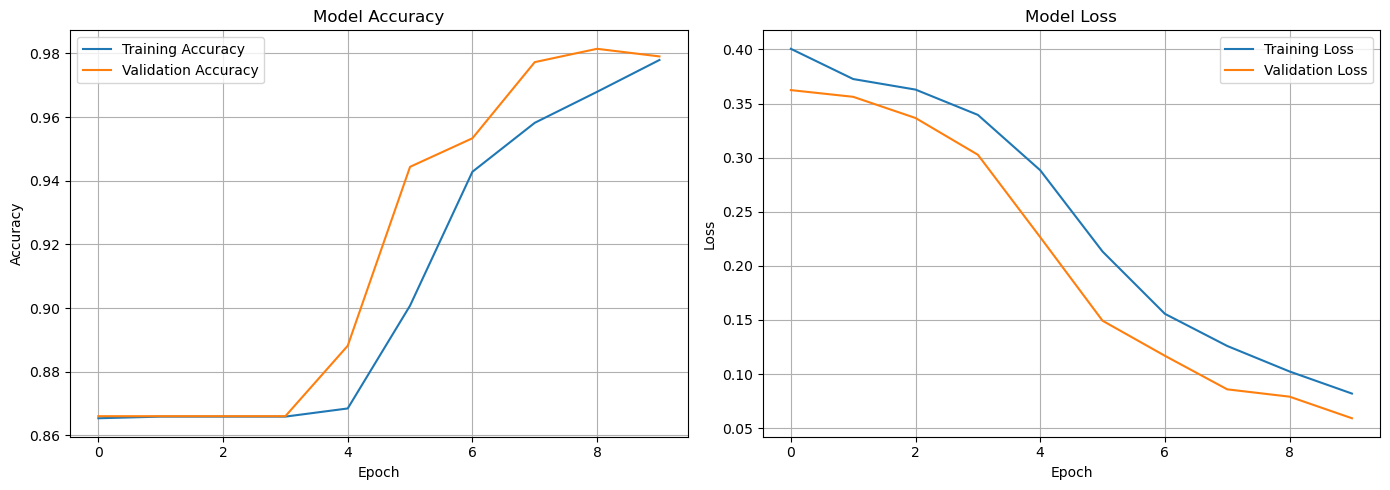

In [103]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Traditional ML** (LogisticRegression, SVC) with TF-IDF or CountVectorizer:
   - Fast to train
   - Interpretable
   - Often performs well on text classification
   - Good baseline models

2. **Neural Networks**:
   - Can learn more complex patterns
   - Require more data and training time
   - Can benefit from pre-trained embeddings (Word2Vec, GloVe, BERT)
   - LSTM/Bidirectional LSTM: better for sequential patterns

3. **When to use what**:
   - Small datasets (<10k samples): Traditional ML often sufficient
   - Large datasets with complex patterns: Neural networks can excel
   - Production systems: Consider inference time and model size

4. **Next steps to explore**:
   - Pre-trained embeddings (Word2Vec, GloVe)
   - Transfer learning with BERT, RoBERTa, etc.
   - Attention mechanisms
   - Multi-task learning